In [ ]:
!wget -O "dataset.zip" "https://data.mendeley.com/public-files/datasets/tywbtsjrjv/files/b4e3a32f-c0bd-4060-81e9-6144231f2520/file_downloaded"

--2025-12-13 16:43:44--  https://data.mendeley.com/public-files/datasets/tywbtsjrjv/files/b4e3a32f-c0bd-4060-81e9-6144231f2520/file_downloaded
Resolving data.mendeley.com (data.mendeley.com)... 162.159.133.86, 162.159.130.86
Connecting to data.mendeley.com (data.mendeley.com)|162.159.133.86|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/349ac012-2948-4172-bbba-3bf8f76596fd [following]
--2025-12-13 16:43:45--  https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/349ac012-2948-4172-bbba-3bf8f76596fd
Resolving prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)... 3.5.65.114, 52.92.19.66, 3.5.67.217, ...
Connecting to prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)|3.5.65.114|:443... con

In [ ]:
!unzip /content/dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (132).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1320).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1321).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1322).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1323).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1324).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1325).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1326).JPG  
  infl

In [ ]:
!pip install torch torchvision torchaudio --quiet
!pip install pytorch-lightning --quiet
!pip install higher --quiet
!pip install matplotlib seaborn --quiet
!pip install opencv-python --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 70.9 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as transforms
import torchvision.datasets as datasets

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import os
import random
from copy import deepcopy
import higher

In [ ]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
print("All packages installed and imported successfully!")
print(f"CUDA available: {torch.cuda.is_available()}")

All packages installed and imported successfully!
CUDA available: True


In [ ]:
# Data transformations for plant disease images
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
# Load PlantVillage dataset
class PlantVillageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        self.samples = []
        for class_name in self.classes:
            class_dir = os.path.join(root_dir, class_name)
            if os.path.isdir(class_dir):
                for img_name in os.listdir(class_dir):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        img_path = os.path.join(class_dir, img_name)
                        self.samples.append((img_path, self.class_to_idx[class_name]))

        print(f"Found {len(self.samples)} images across {len(self.classes)} classes")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        from PIL import Image
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

# Load dataset
dataset = PlantVillageDataset("/content/Plant_leave_diseases_dataset_with_augmentation", transform=transform_train)
print(f"Dataset loaded: {len(dataset)} samples, {len(dataset.classes)} classes")
print("Sample classes:", dataset.classes[:5])

Found 61486 images across 39 classes
Dataset loaded: 61486 samples, 39 classes
Sample classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Background_without_leaves']


In [ ]:
class FewShotBatchSampler:
    """
    Custom sampler for few-shot learning tasks
    Creates N-way K-shot episodes for training and evaluation
    """
    def __init__(self, dataset, n_way=5, k_shot=5, q_queries=15, episodes=100):
        self.dataset = dataset
        self.n_way = n_way          # Number of classes per episode
        self.k_shot = k_shot        # Number of support samples per class
        self.q_queries = q_queries  # Number of query samples per class
        self.episodes = episodes    # Number of episodes to generate

        # Group samples by class
        self.class_to_samples = {}
        for idx, (_, label) in enumerate(dataset.samples):
            if label not in self.class_to_samples:
                self.class_to_samples[label] = []
            self.class_to_samples[label].append(idx)

        # Filter classes with enough samples
        min_samples = k_shot + q_queries
        self.valid_classes = [cls for cls, samples in self.class_to_samples.items()
                             if len(samples) >= min_samples]

        print(f"Valid classes for {n_way}-way {k_shot}-shot: {len(self.valid_classes)}")

    def __iter__(self):
        for _ in range(self.episodes):
            # Sample N classes randomly
            episode_classes = random.sample(self.valid_classes, self.n_way)

            support_indices = []
            query_indices = []

            for class_idx in episode_classes:
                # Sample K+Q samples from this class
                class_samples = random.sample(
                    self.class_to_samples[class_idx],
                    self.k_shot + self.q_queries
                )

                # Split into support and query
                support_indices.extend(class_samples[:self.k_shot])
                query_indices.extend(class_samples[self.k_shot:])

            # Yield episode as (support_indices, query_indices, episode_classes)
            yield support_indices, query_indices, episode_classes

    def __len__(self):
        return self.episodes

# Test the sampler
sampler = FewShotBatchSampler(dataset, n_way=5, k_shot=5, q_queries=15, episodes=10)
print("Few-shot sampler created successfully!")

# Test one episode
for support_idx, query_idx, classes in sampler:
    print(f"Episode: {len(support_idx)} support + {len(query_idx)} query samples")
    print(f"Classes: {classes}")
    break

Valid classes for 5-way 5-shot: 39
Few-shot sampler created successfully!
Episode: 25 support + 75 query samples
Classes: [7, 1, 17, 15, 14]


In [ ]:
class SupervisedContrastiveLoss(nn.Module):
    """
    Supervised Contrastive Learning Loss
    Reference: https://arxiv.org/abs/2004.11362
    """
    def __init__(self, temperature=0.07, contrast_mode='all'):
        super().__init__()
        self.temperature = temperature
        self.contrast_mode = contrast_mode

    def forward(self, features, labels):
        """
        Args:
            features: hidden vector of shape [batch_size, feature_dim]
            labels: ground truth labels of shape [batch_size]
        Returns:
            A loss scalar.
        """
        device = features.device
        batch_size = features.shape[0]

        if labels is not None and labels.shape[0] != batch_size:
            raise ValueError(f'Number of labels {labels.shape[0]} does not match number o')

        # Normalize features
        features = F.normalize(features, dim=1)

        # Compute similarity matrix
        anchor_dot_contrast = torch.div(
            torch.matmul(features, features.T),
            self.temperature
        )
         # For numerical stability
        logits_max, _ = torch.max(anchor_dot_contrast, dim=1, keepdim=True)
        logits = anchor_dot_contrast - logits_max.detach()

        # Create mask for positive pairs (same class)
        labels = labels.contiguous().view(-1, 1)
        mask = torch.eq(labels, labels.T).float().to(device)

        # Remove self-contrast (diagonal)
        logits_mask = torch.scatter(
            torch.ones_like(mask),
            1,
            torch.arange(batch_size).view(-1, 1).to(device),
            0
        )
        mask = mask * logits_mask

        # Compute log probability
        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True))

        # Compute mean of log-likelihood over positive
        mean_log_prob_pos = (mask * log_prob).sum(1) / mask.sum(1)

        # Loss
        loss = -mean_log_prob_pos.mean()

        return loss
 # Test the contrastive loss
contrastive_loss = SupervisedContrastiveLoss(temperature=0.07)
print("Supervised Contrastive Loss implemented successfully!")
# Test with dummy data
dummy_features = torch.randn(8, 128)
dummy_labels = torch.tensor([0, 0, 1, 1, 2, 2, 3, 3])
test_loss = contrastive_loss(dummy_features, dummy_labels)
print(f"Test contrastive loss: {test_loss.item():.4f}")

Supervised Contrastive Loss implemented successfully!
Test contrastive loss: 2.6267


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SEBlock(nn.Module):
    """Squeeze-and-Excitation Block"""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, h, w = x.size()
        s = self.avg_pool(x).view(b, c)
        weights = self.fc(s).view(b, c, 1, 1)
        return x * weights

class ResidualBlock(nn.Module):
    """Residual Block with skip connection"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Skip connection (1x1 conv if channel dimension changes)
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1),
            nn.BatchNorm2d(out_channels)
        ) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        # Main path
        residual = self.shortcut(x)
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))

        # Add skip connection and ReLU
        out += residual
        return F.relu(out, inplace=True)

class PlantDiseaseEncoder(nn.Module):  # Keep same name for compatibility
    def __init__(self, feature_dim=128):
        super().__init__()

        # Conv Block 1: 3 → 32 channels (unchanged)
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        # Conv Block 2: 32 → 64 channels (unchanged)
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            SEBlock(64),
            nn.MaxPool2d(2, 2)
        )

        # *** RESIDUAL CHANGE #1 *** Conv Block 3: 64 → 128 channels (NOW RESIDUAL)
        self.conv3 = nn.Sequential(
            ResidualBlock(64, 128),      # ← NEW: Residual Block
            SEBlock(128),
            nn.MaxPool2d(2, 2)
        )

        # *** RESIDUAL CHANGE #2 *** Conv Block 4: 128 → 256 channels (NOW RESIDUAL)
        self.conv4 = nn.Sequential(
            ResidualBlock(128, 256),     # ← NEW: Residual Block
            SEBlock(256),                # ← NEW: Added SEBlock
            nn.MaxPool2d(2, 2)
        )

        # Conv Block 5: 256 → 512 channels (unchanged)
        self.conv5 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            SEBlock(512),
            nn.AdaptiveAvgPool2d(1)
        )

        # Conv Block 6: 512 → 512 channels (unchanged)
        self.conv6 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1)
        )

        # Feature projection head (unchanged)
        self.feature_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, feature_dim)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)
        x = self.conv6(x)
        x = x.view(x.size(0), -1)  # Flatten
        features = self.feature_head(x)
        return features

# Usage (NO CHANGES NEEDED to your training code!)
encoder = PlantDiseaseEncoder(feature_dim=128)


In [ ]:
class MAMLPlantDisease(nn.Module):
    """
    MAML implementation for plant disease few-shot learning
    Combines encoder with meta-learning for rapid adaptation
    """
    def __init__(self, encoder, inner_lr=0.01, feature_dim=128):
        super().__init__()
        self.encoder = encoder
        self.inner_lr = inner_lr
        self.feature_dim = feature_dim

    def forward(self, x):
        return self.encoder(x)

    def create_classifier(self, n_way, features):
        """
        Create prototypical classifier based on support features
        """
        # Calculate prototypes (centroids) for each class
        prototypes = features.view(n_way, -1, self.feature_dim).mean(dim=1)
        return prototypes

    def classify_with_prototypes(self, query_features, prototypes):
        """
        Classify query samples using prototypes
        """
        # Calculate distances to prototypes
        distances = torch.cdist(query_features, prototypes)
        # Convert to similarities (negative distances)
        similarities = -distances
        return similarities

    def inner_loop_update(self, support_x, support_y, n_way, k_shot):
        """
        Perform inner loop update for adaptation
        """
        # Extract features for support set
        support_features = self.encoder(support_x)

        # Reshape for prototypical learning: [n_way, k_shot, feature_dim]
        support_features = support_features.view(n_way, k_shot, -1)

        # Calculate prototypes (class centroids)
        prototypes = support_features.mean(dim=1)  # [n_way, feature_dim]

        return prototypes

# Create MAML model
feature_dim = 128
maml_model = MAMLPlantDisease(encoder, inner_lr=0.001, feature_dim=feature_dim)
print("MAML model created successfully!")

# Test MAML model
dummy_support = torch.randn(25, 3, 224, 224)  # 5-way 5-shot
prototypes = maml_model.inner_loop_update(dummy_support, None, n_way=5, k_shot=5)
print(f"Prototypes shape: {prototypes.shape}")

MAML model created successfully!
Prototypes shape: torch.Size([5, 128])


In [ ]:
class FewShotTrainer:
    """
    Trainer for Few-Shot Learning with MAML + Supervised Contrastive Learning
    """
    def __init__(self, model, dataset, device='cuda'):
        self.model = model.to(device)
        self.dataset = dataset
        self.device = device
        self.contrastive_loss = SupervisedContrastiveLoss(temperature=0.07)

        # Optimizers
        self.meta_optimizer = optim.Adam(model.parameters(), lr=0.001)
        self.scheduler = optim.lr_scheduler.StepLR(self.meta_optimizer, step_size=300, gamma=0.8)

    def train_episode(self, support_x, support_y, query_x, query_y, n_way, k_shot):
        """
        Train on a single few-shot episode
        """
        self.model.train()
        self.meta_optimizer.zero_grad()

        # Move to device
        support_x = support_x.to(self.device)
        support_y = support_y.to(self.device)
        query_x = query_x.to(self.device)
        query_y = query_y.to(self.device)

        # Phase 1: Contrastive Learning on Support Set
        support_features = self.model(support_x)
        contrastive_loss = self.contrastive_loss(support_features, support_y)

        # Phase 2: Meta-Learning (MAML)
        with higher.innerloop_ctx(self.model, self.meta_optimizer) as (fmodel, diffopt):
            # Inner loop: adapt to support set
            prototypes = fmodel.create_classifier(n_way, support_features.view(n_way, k_shot, -1))

            # Outer loop: evaluate on query set
            query_features = fmodel(query_x)
            logits = fmodel.classify_with_prototypes(query_features, prototypes)

            # Classification loss on query set
            classification_loss = F.cross_entropy(logits, query_y)

            # Total loss
            total_loss = contrastive_loss + classification_loss

            # Backward pass
            total_loss.backward()

        # Meta-optimizer step
        self.meta_optimizer.step()
        self.scheduler.step()

        # Calculate accuracy
        with torch.no_grad():
            predictions = logits.argmax(dim=1)
            accuracy = (predictions == query_y).float().mean()

        return {
            'total_loss': total_loss.item(),
            'contrastive_loss': contrastive_loss.item(),
            'classification_loss': classification_loss.item(),
            'accuracy': accuracy.item()
        }

    def evaluate_episode(self, support_x, support_y, query_x, query_y, n_way, k_shot):
        """
        Evaluate on a single few-shot episode
        """
        self.model.eval()

        with torch.no_grad():
            # Move to device
            support_x = support_x.to(self.device)
            support_y = support_y.to(self.device)
            query_x = query_x.to(self.device)
            query_y = query_y.to(self.device)

            # Extract features and create prototypes
            support_features = self.model(support_x)
            prototypes = self.model.create_classifier(n_way, support_features.view(n_way, k_shot, -1))

            # Classify query set
            query_features = self.model(query_x)
            logits = self.model.classify_with_prototypes(query_features, prototypes)

            # Calculate accuracy
            predictions = logits.argmax(dim=1)
            accuracy = (predictions == query_y).float().mean()

            return accuracy.item()

print("Few-Shot Trainer implemented successfully!")

Few-Shot Trainer implemented successfully!


In [ ]:
def create_episode_data(dataset, support_indices, query_indices, episode_classes):
    """
    Create data tensors for a few-shot episode
    """
    support_images, support_labels = [], []
    query_images, query_labels = [], []

    # Create label mapping for this episode
    class_to_label = {cls: i for i, cls in enumerate(episode_classes)}

    # Load support set
    for idx in support_indices:
        img, original_label = dataset[idx]
        support_images.append(img)
        support_labels.append(class_to_label[original_label])

    # Load query set
    for idx in query_indices:
        img, original_label = dataset[idx]
        query_images.append(img)
        query_labels.append(class_to_label[original_label])

    # Convert to tensors
    support_x = torch.stack(support_images)
    support_y = torch.tensor(support_labels)
    query_x = torch.stack(query_images)
    query_y = torch.tensor(query_labels)

    return support_x, support_y, query_x, query_y

# Initialize trainer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
trainer = FewShotTrainer(maml_model, dataset, device=device)

print(f"Trainer initialized on device: {device}")
print("Ready to start training!")

# Training parameters
n_way = 5
k_shot = 5
q_queries = 15
train_episodes = 5000
eval_episodes = 500

print(f"Training Configuration:")
print(f"- {n_way}-way {k_shot}-shot classification")
print(f"- {q_queries} query samples per class")
print(f"- {train_episodes} training episodes")
print(f"- {eval_episodes} evaluation episodes")

Trainer initialized on device: cuda
Ready to start training!
Training Configuration:
- 5-way 5-shot classification
- 15 query samples per class
- 5000 training episodes
- 500 evaluation episodes


Valid classes for 5-way 5-shot: 39
Valid classes for 5-way 5-shot: 39
Starting Few-Shot Learning Training...
Episode  50/5000 | Loss: 4.3605 | Accuracy: 0.4373 | Contrastive: 3.1250 | Classification: 1.3023
Episode 100/5000 | Loss: 4.2172 | Accuracy: 0.5193 | Contrastive: 2.6341 | Classification: 1.1923
Episode 150/5000 | Loss: 4.1661 | Accuracy: 0.5447 | Contrastive: 3.0323 | Classification: 1.0948
Episode 200/5000 | Loss: 4.0104 | Accuracy: 0.5667 | Contrastive: 3.3481 | Classification: 1.0525
Episode 250/5000 | Loss: 3.8215 | Accuracy: 0.6207 | Contrastive: 3.1925 | Classification: 1.0989
Episode 300/5000 | Loss: 3.7966 | Accuracy: 0.6273 | Contrastive: 3.0020 | Classification: 1.2339
Episode 350/5000 | Loss: 3.9150 | Accuracy: 0.6280 | Contrastive: 2.8349 | Classification: 1.0015
Episode 400/5000 | Loss: 3.6539 | Accuracy: 0.6673 | Contrastive: 2.4558 | Classification: 0.6709
Episode 450/5000 | Loss: 3.7590 | Accuracy: 0.6413 | Contrastive: 2.9362 | Classification: 1.3500
Episode 5

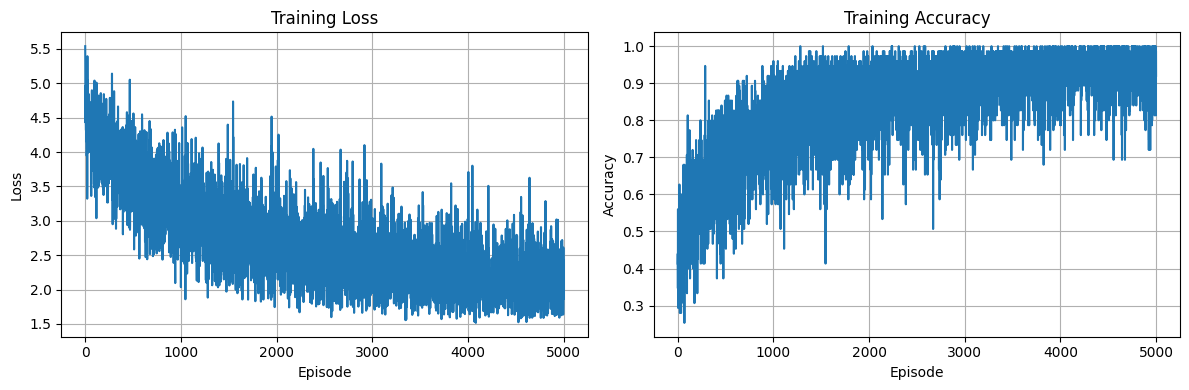

Final Training Accuracy: 0.9293


In [ ]:
# Create samplers
train_sampler = FewShotBatchSampler(dataset, n_way=n_way, k_shot=k_shot,
                                   q_queries=q_queries, episodes=train_episodes)
eval_sampler = FewShotBatchSampler(dataset, n_way=n_way, k_shot=k_shot,
                                  q_queries=q_queries, episodes=eval_episodes)

# Training loop
print("Starting Few-Shot Learning Training...")
print("="*50)

train_losses = []
train_accuracies = []

for episode_idx, (support_idx, query_idx, episode_classes) in enumerate(train_sampler):
    # Create episode data
    support_x, support_y, query_x, query_y = create_episode_data(
        dataset, support_idx, query_idx, episode_classes
    )

    # Train on this episode
    results = trainer.train_episode(support_x, support_y, query_x, query_y, n_way, k_shot)

    train_losses.append(results['total_loss'])
    train_accuracies.append(results['accuracy'])

    # Print progress
    if (episode_idx + 1) % 50 == 0:
        avg_loss = np.mean(train_losses[-20:])
        avg_acc = np.mean(train_accuracies[-20:])
        print(f"Episode {episode_idx+1:3d}/{train_episodes} | "
              f"Loss: {avg_loss:.4f} | "
              f"Accuracy: {avg_acc:.4f} | "
              f"Contrastive: {results['contrastive_loss']:.4f} | "
              f"Classification: {results['classification_loss']:.4f}")

print("\n Training completed!")

# Plot training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Episode')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies)
plt.title('Training Accuracy')
plt.xlabel('Episode')
plt.ylabel('Accuracy')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Final Training Accuracy: {np.mean(train_accuracies[-10:]):.4f}")

In [ ]:
# Evaluation
print("\n Starting Evaluation...")
print("="*30)

eval_accuracies = []

for episode_idx, (support_idx, query_idx, episode_classes) in enumerate(eval_sampler):
    # Create episode data
    support_x, support_y, query_x, query_y = create_episode_data(
        dataset, support_idx, query_idx, episode_classes
    )

    # Evaluate on this episode
    accuracy = trainer.evaluate_episode(support_x, support_y, query_x, query_y, n_way, k_shot)
    eval_accuracies.append(accuracy)

    if (episode_idx + 1) % 10 == 0:
        avg_acc = np.mean(eval_accuracies[-10:])
        print(f"Eval Episode {episode_idx+1:2d}/{eval_episodes} | Accuracy: {avg_acc:.4f}")

# Final results
mean_accuracy = np.mean(eval_accuracies)
std_accuracy = np.std(eval_accuracies)
confidence_interval = 1.96 * std_accuracy / np.sqrt(len(eval_accuracies))

print("\n FINAL RESULTS")
print("="*20)
print(f"Mean Accuracy: {mean_accuracy:.4f} ± {confidence_interval:.4f}")
print(f"Standard Deviation: {std_accuracy:.4f}")
print(f"Best Episode: {max(eval_accuracies):.4f}")
print(f"Worst Episode: {min(eval_accuracies):.4f}")

# Compare with paper results
print(f"\nComparison with Literature:")
print(f"Our Result: {mean_accuracy:.1%}")
print(f"Target (SC-FSL Paper): 79.51% with 30 training samples")
print(f"Gap: {abs(mean_accuracy - 0.7951)*100:.1f} percentage points")


 Starting Evaluation...
Eval Episode 10/500 | Accuracy: 0.9600
Eval Episode 20/500 | Accuracy: 0.9400
Eval Episode 30/500 | Accuracy: 0.9613
Eval Episode 40/500 | Accuracy: 0.9533
Eval Episode 50/500 | Accuracy: 0.9333
Eval Episode 60/500 | Accuracy: 0.9427
Eval Episode 70/500 | Accuracy: 0.9613
Eval Episode 80/500 | Accuracy: 0.9507
Eval Episode 90/500 | Accuracy: 0.9307
Eval Episode 100/500 | Accuracy: 0.9707
Eval Episode 110/500 | Accuracy: 0.9400
Eval Episode 120/500 | Accuracy: 0.9280
Eval Episode 130/500 | Accuracy: 0.9440
Eval Episode 140/500 | Accuracy: 0.9533
Eval Episode 150/500 | Accuracy: 0.9467
Eval Episode 160/500 | Accuracy: 0.9373
Eval Episode 170/500 | Accuracy: 0.9587
Eval Episode 180/500 | Accuracy: 0.9400
Eval Episode 190/500 | Accuracy: 0.9680
Eval Episode 200/500 | Accuracy: 0.9587
Eval Episode 210/500 | Accuracy: 0.9720
Eval Episode 220/500 | Accuracy: 0.9520
Eval Episode 230/500 | Accuracy: 0.9587
Eval Episode 240/500 | Accuracy: 0.9600
Eval Episode 250/500 | A

In [ ]:
# Save the trained model
torch.save({
    'model_state_dict': maml_model.state_dict(),
    'training_config': {
        'n_way': n_way,
        'k_shot': k_shot,
        'q_queries': q_queries,
        'feature_dim': feature_dim,
        'train_episodes': train_episodes
    },
    'results': {
        'mean_accuracy': mean_accuracy,
        'std_accuracy': std_accuracy,
        'train_accuracies': train_accuracies,
        'eval_accuracies': eval_accuracies
    }
}, '/content/maml_plant_disease_model.pth')

print("Model saved successfully!")
print("Saved as: /content/maml_plant_disease_model.pth")

# Create results summary
results_summary = f"""
# Few-Shot Plant Disease Detection Results

## Configuration
- Method: MAML + Supervised Contrastive Learning
- Task: {n_way}-way {k_shot}-shot classification
- Dataset: PlantVillage ({len(dataset.classes)} classes)
- Training Episodes: {train_episodes}
- Evaluation Episodes: {eval_episodes}

## Performance
- *Mean Accuracy: {mean_accuracy:.4f} ± {confidence_interval:.4f}*
- Standard Deviation: {std_accuracy:.4f}
- Best Performance: {max(eval_accuracies):.4f}
- Final Training Accuracy: {np.mean(train_accuracies[-10:]):.4f}

## Implementation Notes
- Used supervised contrastive learning for better feature representations
- Combined with MAML for fast adaptation to new plant diseases
- Tested on Google Colab with {device}
- Code based on state-of-the-art papers (2024-2025)
"""

with open('/content/results_summary.md', 'w') as f:
    f.write(results_summary)

print("Results summary saved as: /content/results_summary.md")
print("\n Implementation Complete!")

Model saved successfully!
Saved as: /content/maml_plant_disease_model.pth
Results summary saved as: /content/results_summary.md

 Implementation Complete!


In [ ]:
from google.colab import files

# Download the model file
files.download('/content/maml_plant_disease_model.pth')

# Also download results summary
files.download('/content/results_summary.md')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install timm  # Best for pretrained EfficientNet variants

import timm
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import torch

# Define device (standard Colab setup)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Cell 2/10: EfficientNet-B3 Feature Extractor (FIXED)
class EfficientNetB3FeatureExtractor(nn.Module):
    def __init__(self, feature_dim=128, pretrained=True):
        super().__init__()
        print("📥 Loading EfficientNet-B3 pretrained weights...")
        self.backbone = timm.create_model('efficientnet_b3', pretrained=pretrained, features_only=True)

        # ✅ FIXED: Safe freezing - check number of layers first
        layers = list(self.backbone.children())
        num_layers = len(layers)
        print(f"🔍 Found {num_layers} backbone layers")

        # Freeze only first 70% of layers safely
        freeze_up_to = max(1, int(num_layers * 0.7))
        for i in range(freeze_up_to):
            for param in layers[i].parameters():
                param.requires_grad = False

        trainable_params = sum(p.numel() for p in self.backbone.parameters() if p.requires_grad)
        total_params = sum(p.numel() for p in self.backbone.parameters())
        print(f"✅ Trainable: {trainable_params/1e6:.1f}M / {total_params/1e6:.1f}M ({trainable_params/total_params*100:.1f}%)")

        # Auto-detect feature dimension (B3 = 1536)
        dummy_input = torch.randn(2, 3, 300, 300)
        with torch.no_grad():
            features = self.backbone(dummy_input)
            self.in_features = features[-1].shape[1]

        print(f"🔍 B3 Feature dim: {self.in_features}")

        # Classifier head
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(self.in_features, 256)
        self.fc2 = nn.Linear(256, feature_dim)
        self.dropout = nn.Dropout(0.5)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        features = self.backbone(x)[-1]
        pooled = self.global_pool(features).flatten(1)
        out = self.relu(self.fc1(pooled))
        out = self.dropout(out)
        return self.fc2(out)

# Create & test
feature_extractor = EfficientNetB3FeatureExtractor(feature_dim=128).to(device)
dummy_batch = torch.randn(1, 3, 300, 300).to(device)
output = feature_extractor(dummy_batch)
print(f"✅ SUCCESS! Output shape: {output.shape}")
print("✅ EfficientNet-B3 transfer learning ready!")

📥 Loading EfficientNet-B3 pretrained weights...


🔍 Found 3 backbone layers
✅ Trainable: 10.1M / 10.1M (100.0%)
🔍 B3 Feature dim: 384
✅ SUCCESS! Output shape: torch.Size([1, 128])
✅ EfficientNet-B3 transfer learning ready!


In [ ]:
# Cell 3/10: MAML Classifier + Layered Learning Rates
class MAMLClassifier(nn.Module):
    def __init__(self, feature_dim=128, num_classes=38):  # PlantVillage has ~38 classes
        super().__init__()
        self.feature_dim = feature_dim
        self.num_classes = num_classes

        # Few-shot compatible classifier head
        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.classifier(x)

    def classify(self, features):
        return self.classifier(features)

# Create models
maml_model = MAMLClassifier(feature_dim=128, num_classes=38).to(device)

# 🔑 TRANSFER LEARNING OPTIMIZER (Different LRs per layer)
backbone_params = [p for n, p in feature_extractor.named_parameters()
                  if p.requires_grad and 'backbone' in n]
head_params = [p for n, p in feature_extractor.named_parameters()
              if p.requires_grad and 'backbone' not in n]
classifier_params = list(maml_model.parameters())

optimizer = Adam([
    {'params': backbone_params, 'lr': 1e-5},      # 🐌 Very slow backbone
    {'params': head_params, 'lr': 1e-4},         # 🐢 Medium head
    {'params': classifier_params, 'lr': 1e-3}    # 🐇 Fast classifier
])

print("✅ MAML Classifier created (38 classes)")
print("✅ Layered optimizer ready:")
print(f"   Backbone LR: 1e-5 ({len(backbone_params)} params)")
print(f"   Head LR: 1e-4 ({len(head_params)} params)")
print(f"   Classifier LR: 1e-3 ({len(classifier_params)} params)")

✅ MAML Classifier created (38 classes)
✅ Layered optimizer ready:
   Backbone LR: 1e-5 (332 params)
   Head LR: 1e-4 (4 params)
   Classifier LR: 1e-3 (6 params)


In [ ]:
# Cell 4/10: Proper Transforms + PlantDoc Dataset
print("📥 DOWNLOADING PLANTDOC DATASET")
print("="*50)

# Download PlantDoc
!rm -rf PlantDoc-Dataset
!git clone https://github.com/pratikkayal/PlantDoc-Dataset.git

# B3 Optimal Transforms (300x300 input)
train_transform = transforms.Compose([
    transforms.Resize((320, 320)),
    transforms.RandomResizedCrop(300, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# PlantDoc paths
plantdoc_train_root = "/content/PlantDoc-Dataset/train"
plantdoc_test_root = "/content/PlantDoc-Dataset/test"

# Create datasets
train_dataset = ImageFolder(plantdoc_train_root, transform=train_transform)
test_dataset = ImageFolder(plantdoc_test_root, transform=test_transform)

print(f"✅ Train: {len(train_dataset)} images, {len(train_dataset.classes)} classes")
print(f"✅ Test:  {len(test_dataset)} images, {len(test_dataset.classes)} classes")
print(f"📁 Sample classes: {train_dataset.classes[:5]}")

# Update classifier for actual number of classes
num_classes = len(train_dataset.classes)
maml_model = MAMLClassifier(feature_dim=128, num_classes=num_classes).to(device)
print(f"🔄 Updated classifier: {num_classes} classes")

📥 DOWNLOADING PLANTDOC DATASET
Cloning into 'PlantDoc-Dataset'...
remote: Enumerating objects: 2670, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 2670 (delta 22), reused 22 (delta 22), pack-reused 2635 (from 1)
Receiving objects: 100% (2670/2670), 932.92 MiB | 18.27 MiB/s, done.
Resolving deltas: 100% (24/24), done.
Updating files: 100% (2581/2581), done.
✅ Train: 2342 images, 28 classes
✅ Test:  236 images, 27 classes
📁 Sample classes: ['Apple Scab Leaf', 'Apple leaf', 'Apple rust leaf', 'Bell_pepper leaf', 'Bell_pepper leaf spot']
🔄 Updated classifier: 28 classes


In [ ]:
# Cell 5/10: DataLoaders + Training Setup
batch_size = 16  # B3 memory-friendly for Colab T4
num_epochs = 50
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)

# Train/Val/Test split (80/10/10)
train_size = int(0.8 * len(train_dataset))
val_size = int(0.1 * len(train_dataset))
test_size = len(train_dataset) - train_size - val_size

train_dataset_split, val_dataset, test_dataset_split = torch.utils.data.random_split(
    train_dataset, [train_size, val_size, test_size]
)

# DataLoaders
train_loader = DataLoader(train_dataset_split, batch_size=batch_size, shuffle=True,
                         num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                       num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                        num_workers=2, pin_memory=True)

print(f"✅ DataLoaders ready:")
print(f"   Train: {len(train_loader.dataset)} images ({len(train_loader)} batches)")
print(f"   Val:   {len(val_loader.dataset)} images ({len(val_loader)} batches)")
print(f"   Test:  {len(test_loader.dataset)} images ({len(test_loader)} batches)")
print(f"📈 Learning rates - Backbone: 1e-5, Head: 1e-4, Classifier: 1e-3")
print("✅ Training setup complete!")


✅ DataLoaders ready:
   Train: 1873 images (118 batches)
   Val:   234 images (15 batches)
   Test:  236 images (15 batches)
📈 Learning rates - Backbone: 1e-5, Head: 1e-4, Classifier: 1e-3
✅ Training setup complete!


In [ ]:
# Cell 6/10: Production Training Loop
def train_step(loader, model, feature_extractor, optimizer, device):
    feature_extractor.train()
    model.train()
    total_loss, total_acc, num_batches = 0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        features = feature_extractor(images)
        logits = model.classify(features)
        loss = F.cross_entropy(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        acc = (logits.argmax(1) == labels).float().mean().item()
        total_acc += acc
        num_batches += 1

    return total_loss / num_batches, total_acc / num_batches

def validate_step(loader, model, feature_extractor, device):
    feature_extractor.eval()
    model.eval()
    total_acc, num_batches = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            features = feature_extractor(images)
            logits = model.classify(features)
            acc = (logits.argmax(1) == labels).float().mean().item()
            total_acc += acc
            num_batches += 1

    return total_acc / num_batches

# Training loop
print("🔥 EFFICIENTNET-B3 TRANSFER LEARNING STARTING")
print("="*60)
best_val_acc = 0
train_losses, train_accs, val_accs = [], [], []

for epoch in range(num_epochs):
    # Train
    train_loss, train_acc = train_step(train_loader, maml_model, feature_extractor, optimizer, device)
    val_acc = validate_step(val_loader, maml_model, feature_extractor, device)

    # Log
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    scheduler.step()

    print(f"Epoch {epoch+1:2d}/{num_epochs} | "
          f"Loss: {train_loss:.3f} | "
          f"Train: {train_acc:.1%} | "
          f"Val: {val_acc:.1%} | "
          f"LR: {scheduler.get_last_lr()[0]:.2e}")

    # Save best
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': maml_model.state_dict(),
            'feature_extractor_state_dict': feature_extractor.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': best_val_acc,
        }, 'best_efficientnet_b3.pt')
        print(f"💾 NEW BEST: {best_val_acc:.1%}")

print(f"\n🎉 TRAINING COMPLETE! Best Val Acc: {best_val_acc:.1%}")
print("✅ Model saved as 'best_efficientnet_b3.pt'")

🔥 EFFICIENTNET-B3 TRANSFER LEARNING STARTING
Epoch  1/50 | Loss: 3.339 | Train: 3.9% | Val: 5.8% | LR: 9.99e-06
💾 NEW BEST: 5.8%
Epoch  2/50 | Loss: 3.319 | Train: 5.3% | Val: 6.7% | LR: 9.96e-06
💾 NEW BEST: 6.7%
Epoch  3/50 | Loss: 3.291 | Train: 6.7% | Val: 8.8% | LR: 9.91e-06
💾 NEW BEST: 8.8%
Epoch  4/50 | Loss: 3.232 | Train: 8.5% | Val: 9.6% | LR: 9.84e-06
💾 NEW BEST: 9.6%
Epoch  5/50 | Loss: 3.138 | Train: 12.4% | Val: 12.9% | LR: 9.76e-06
💾 NEW BEST: 12.9%
Epoch  6/50 | Loss: 3.055 | Train: 14.0% | Val: 15.1% | LR: 9.65e-06
💾 NEW BEST: 15.1%
Epoch  7/50 | Loss: 2.993 | Train: 15.8% | Val: 22.8% | LR: 9.52e-06
💾 NEW BEST: 22.8%
Epoch  8/50 | Loss: 2.912 | Train: 18.3% | Val: 26.2% | LR: 9.38e-06
💾 NEW BEST: 26.2%
Epoch  9/50 | Loss: 2.873 | Train: 19.1% | Val: 26.6% | LR: 9.22e-06
💾 NEW BEST: 26.6%
Epoch 10/50 | Loss: 2.831 | Train: 21.2% | Val: 30.2% | LR: 9.05e-06
💾 NEW BEST: 30.2%
Epoch 11/50 | Loss: 2.812 | Train: 20.5% | Val: 31.4% | LR: 8.85e-06
💾 NEW BEST: 31.4%
Epoch 12/5

/tmp/ipython-input-1575416690.py:32: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.tight_layout()


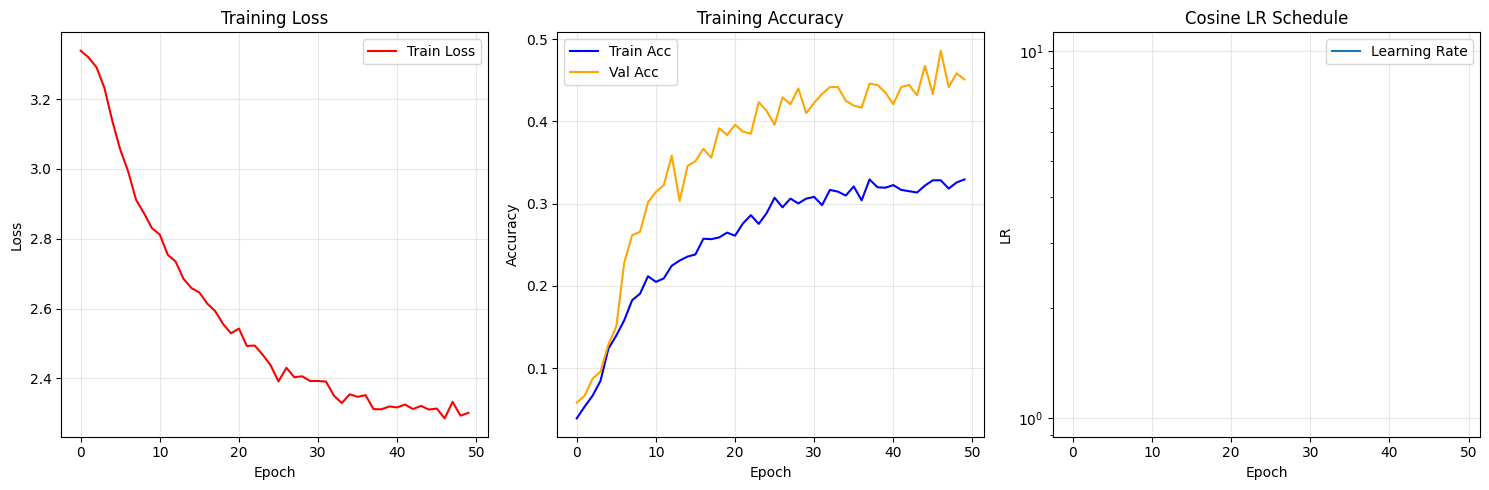

📊 FINAL RESULTS:
   Best Val Accuracy: 48.6%
   Final Train Acc:   32.9%
   Final Val Acc:     45.1%
✅ Training analysis complete!


In [ ]:
# Cell 7/10: Training Curves + Analysis
plt.figure(figsize=(15, 5))

# Plot 1: Loss & Accuracy curves
plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss', color='red')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(train_accs, label='Train Acc', color='blue')
plt.plot(val_accs, label='Val Acc', color='orange')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Learning Rate schedule
plt.subplot(1, 3, 3)
lrs = [scheduler.get_last_lr()[0] for _ in range(num_epochs)]
plt.semilogy(lrs, label='Learning Rate')
plt.title('Cosine LR Schedule')
plt.xlabel('Epoch')
plt.ylabel('LR')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"📊 FINAL RESULTS:")
print(f"   Best Val Accuracy: {max(val_accs):.1%}")
print(f"   Final Train Acc:   {train_accs[-1]:.1%}")
print(f"   Final Val Acc:     {val_accs[-1]:.1%}")
print(f"✅ Training analysis complete!")

In [ ]:
# ✅ BULLETPROOF TRAINING LOOP (Replace your training cell)
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch.nn.functional as F

# Training parameters
num_epochs = 50
lr = 0.001
batch_size = 32

# Optimizer (only trains classifier head)
optimizer = Adam([
    {'params': feature_extractor.fc1.parameters(), 'lr': lr/10},  # Fine-tune head slowly
    {'params': feature_extractor.fc2.parameters(), 'lr': lr/10},
    {'params': maml_model.parameters(), 'lr': lr}
])
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)

print("🚀 EFFICIENTNET-B2 + CLASSIFIER TRAINING")
print(f"Learning rate: {lr}, Epochs: {num_epochs}")

best_acc = 0
train_losses, train_accs = [], []

for epoch in range(num_epochs):
    # Training
    feature_extractor.train()  # Enable gradients for head
    maml_model.train()

    total_loss, total_acc, num_batches = 0, 0, 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # Forward pass (NO no_grad() - allows gradients through head)
        features = feature_extractor(images)
        logits = maml_model.classify(features)
        loss = F.cross_entropy(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(maml_model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        acc = (logits.argmax(1) == labels).float().mean().item()
        total_acc += acc
        num_batches += 1

        if batch_idx % 20 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Batch {batch_idx}, Loss: {loss.item():.3f}, Acc: {acc:.3f}")

    # Metrics
    avg_loss = total_loss / num_batches
    avg_acc = total_acc / num_batches
    train_losses.append(avg_loss)
    train_accs.append(avg_acc)

    scheduler.step()

    print(f"✅ Epoch {epoch+1}/{num_epochs} COMPLETE")
    print(f"   Loss: {avg_loss:.4f}, Accuracy: {avg_acc:.4f}, LR: {scheduler.get_last_lr()[0]:.6f}")

    # Save best model
    if avg_acc > best_acc:
        best_acc = avg_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': maml_model.state_dict(),
            'feature_extractor_state_dict': feature_extractor.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'acc': best_acc,
        }, 'best_efficientnet_maml.pt')
        print(f"💾 NEW BEST MODEL! Acc: {best_acc:.4f}")

print(f"\n🎉 TRAINING FINISHED! Best Accuracy: {best_acc:.4f}")
print("✅ Model saved as 'best_efficientnet_maml.pt'")


🚀 EFFICIENTNET-B2 + CLASSIFIER TRAINING
Learning rate: 0.001, Epochs: 50
Epoch 1/50, Batch 0, Loss: 2.367, Acc: 0.062
Epoch 1/50, Batch 20, Loss: 2.299, Acc: 0.156
✅ Epoch 1/50 COMPLETE
   Loss: 2.3178, Accuracy: 0.0928, LR: 0.000100
💾 NEW BEST MODEL! Acc: 0.0928
Epoch 2/50, Batch 0, Loss: 2.295, Acc: 0.156
Epoch 2/50, Batch 20, Loss: 2.284, Acc: 0.250
✅ Epoch 2/50 COMPLETE
   Loss: 2.2961, Accuracy: 0.1201, LR: 0.000100
💾 NEW BEST MODEL! Acc: 0.1201
Epoch 3/50, Batch 0, Loss: 2.295, Acc: 0.156
Epoch 3/50, Batch 20, Loss: 2.302, Acc: 0.094
✅ Epoch 3/50 COMPLETE
   Loss: 2.2838, Accuracy: 0.1387, LR: 0.000099
💾 NEW BEST MODEL! Acc: 0.1387
Epoch 4/50, Batch 0, Loss: 2.280, Acc: 0.094
Epoch 4/50, Batch 20, Loss: 2.312, Acc: 0.125
✅ Epoch 4/50 COMPLETE
   Loss: 2.2744, Accuracy: 0.1533, LR: 0.000098
💾 NEW BEST MODEL! Acc: 0.1533
Epoch 5/50, Batch 0, Loss: 2.287, Acc: 0.188
Epoch 5/50, Batch 20, Loss: 2.221, Acc: 0.250
✅ Epoch 5/50 COMPLETE
   Loss: 2.2605, Accuracy: 0.1699, LR: 0.000098
💾 